# ⚡ Spark JSON ETL — Customer Orders
A complete PySpark ETL pipeline:
- Read JSON (orders + customers)
- Transform & enrich
- Aggregations
- Write output (Parquet + CSV)
- Convert Spark → Pandas → Visualization


## 1. Start Spark Session

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum as spark_sum, to_date, round as spark_round

spark = SparkSession.builder.appName("Spark JSON ETL").getOrCreate()
spark

## 2. Create JSON Files (Orders + Customers)

In [3]:
import json

orders_json_lines = [
    {"order_id": 1, "customer_id": 1001, "amount": 120.50, "date": "2024-01-01"},
    {"order_id": 2, "customer_id": 1002, "amount": 75.00, "date": "2024-01-01"},
    {"order_id": 3, "customer_id": 1003, "amount": 200.00, "date": "2024-01-02"},
    {"order_id": 4, "customer_id": 1001, "amount": 50.00, "date": "2024-01-03"},
    {"order_id": 5, "customer_id": 1004, "amount": 300.00, "date": "2024-01-03"}
]

customers_json_lines = [
    {"customer_id": 1001, "name": "Alice", "city": "New York"},
    {"customer_id": 1002, "name": "Bob", "city": "Chicago"},
    {"customer_id": 1003, "name": "Charlie", "city": "Houston"},
    {"customer_id": 1004, "name": "David", "city": "Los Angeles"}
]

# Write JSON Lines (Spark-friendly)
with open("orders_spark.json", "w") as f:
    for row in orders_json_lines:
        f.write(json.dumps(row) + "\n")

with open("customers_spark.json", "w") as f:
    for row in customers_json_lines:
        f.write(json.dumps(row) + "\n")


## 3. Read JSON Files into Spark DataFrames

In [4]:
orders_df = spark.read.json("orders_spark.json")
customers_df = spark.read.json("customers_spark.json")

orders_df.show()
customers_df.show()

+------+-----------+----------+--------+
|amount|customer_id|      date|order_id|
+------+-----------+----------+--------+
| 120.5|       1001|2024-01-01|       1|
|  75.0|       1002|2024-01-01|       2|
| 200.0|       1003|2024-01-02|       3|
|  50.0|       1001|2024-01-03|       4|
| 300.0|       1004|2024-01-03|       5|
+------+-----------+----------+--------+

+-----------+-----------+-------+
|       city|customer_id|   name|
+-----------+-----------+-------+
|   New York|       1001|  Alice|
|    Chicago|       1002|    Bob|
|    Houston|       1003|Charlie|
|Los Angeles|       1004|  David|
+-----------+-----------+-------+



## 4. Transform — Clean & Enrich

In [5]:
orders_typed_df = orders_df.withColumn("date", to_date(col("date"), "yyyy-MM-dd"))

merged_df = orders_typed_df.join(customers_df, on="customer_id", how="left")

# merged_df = merged_df.withColumn(
#     "amount_with_tax",
#     spark_round(col("amount") * 1.07, 2)
# )

merged_df.show()

+-----------+------+----------+--------+-----------+-------+
|customer_id|amount|      date|order_id|       city|   name|
+-----------+------+----------+--------+-----------+-------+
|       1001| 120.5|2024-01-01|       1|   New York|  Alice|
|       1002|  75.0|2024-01-01|       2|    Chicago|    Bob|
|       1003| 200.0|2024-01-02|       3|    Houston|Charlie|
|       1001|  50.0|2024-01-03|       4|   New York|  Alice|
|       1004| 300.0|2024-01-03|       5|Los Angeles|  David|
+-----------+------+----------+--------+-----------+-------+



In [11]:
# Approach 2: We can convert the DF into SQL like table/view and write SQL queries. ******
orders_df.createOrReplaceTempView("orders")
customers_df.createOrReplaceTempView("customers")

spark.sql("""
select ord.customer_id,  ord.amount,  ord.date,  ord.order_id, cust.city, cust.name FROM orders ord 
    LEFT JOIN customers cust
    on ord.customer_id = cust.customer_id
""").show()

+-----------+------+----------+--------+-----------+-------+
|customer_id|amount|      date|order_id|       city|   name|
+-----------+------+----------+--------+-----------+-------+
|       1001| 120.5|2024-01-01|       1|   New York|  Alice|
|       1002|  75.0|2024-01-01|       2|    Chicago|    Bob|
|       1003| 200.0|2024-01-02|       3|    Houston|Charlie|
|       1001|  50.0|2024-01-03|       4|   New York|  Alice|
|       1004| 300.0|2024-01-03|       5|Los Angeles|  David|
+-----------+------+----------+--------+-----------+-------+



## 5. Aggregations — Real Metrics

In [14]:
total_revenue_df = merged_df.agg(spark_sum("amount").alias("total_revenue"))
revenue_by_city_df = merged_df.groupBy("city").agg(spark_sum("amount").alias("revenue"))
daily_revenue_df = merged_df.groupBy("date").agg(spark_sum("amount").alias("revenue"))

total_revenue_df.show()
revenue_by_city_df.show()
daily_revenue_df.show()

+-------------+
|total_revenue|
+-------------+
|        745.5|
+-------------+

+-----------+-------+
|       city|revenue|
+-----------+-------+
|Los Angeles|  300.0|
|    Chicago|   75.0|
|    Houston|  200.0|
|   New York|  170.5|
+-----------+-------+

+----------+-------+
|      date|revenue|
+----------+-------+
|2024-01-02|  200.0|
|2024-01-03|  350.0|
|2024-01-01|  195.5|
+----------+-------+



## 6. Load — Write Output (Parquet + CSV)

In [16]:
# merged_df.write.mode("overwrite").parquet("orders_etl_parquet")
# merged_df.write.mode("overwrite").csv("orders_etl_csv", header=True)

revenue_by_city_df.write.mode("overwrite").csv("revenue_by_city_csv", header=True)
daily_revenue_df.write.mode("overwrite").csv("daily_revenue_csv", header=True)

## 7. Visualization (Spark → Pandas → Seaborn)

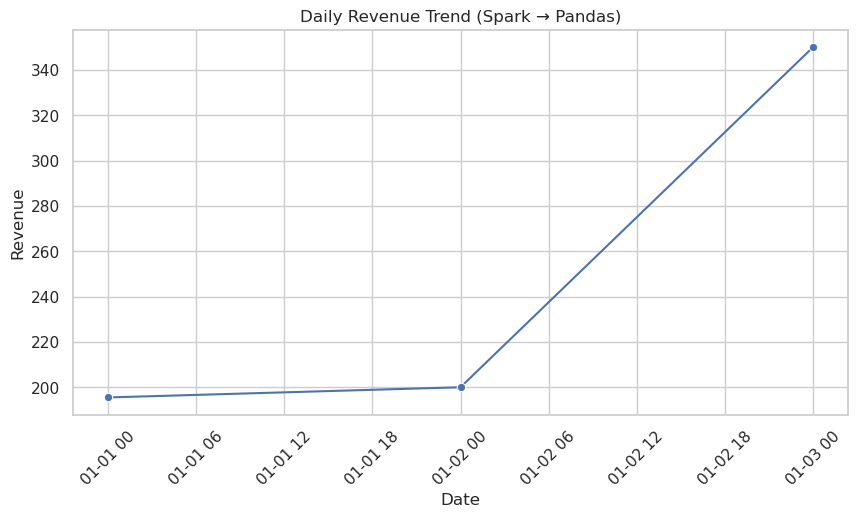

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

revenue_by_city_pd = revenue_by_city_df.toPandas()
daily_revenue_pd = daily_revenue_df.toPandas()

# plt.figure(figsize=(8,5))
# sns.barplot(x=revenue_by_city_pd['city'], y=revenue_by_city_pd['revenue'])
# plt.title('Revenue by City (Spark → Pandas)')
# plt.xlabel('City')
# plt.ylabel('Revenue')
# plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(x=daily_revenue_pd['date'], y=daily_revenue_pd['revenue'], marker='o')
plt.title('Daily Revenue Trend (Spark → Pandas)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### Complete - working Spark JSON ETL pipeline.